In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [ ]:
# Base dataset
df = pd.read_csv("../../Data/Processed/renttherunway_clean.csv")

# GMM clusters
gmm = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/gmm_df.csv")[["user_id", "item_id", "body_cluster", "cluster_confidence"]]

# DBSCAN clusters
dbscan = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/dbscan_df.csv")[["user_id", "dbscan_cluster"]]

# K-Means clusters
kmeans = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/kmeans_clusters.csv").rename(columns={"cluster": "kmeans_cluster"})

# LDA topic features
lda = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv")

In [3]:
df = df.merge(
    dbscan,
    on="user_id",
    how="left"
)

In [4]:
df = df.merge(
    gmm,
    on=["user_id", "item_id"],
    how="left"
)

In [5]:
df = df.merge(
    kmeans,
    on=["user_id", "item_id"],
    how="left"
)

In [6]:
df = df.merge(
    lda,
    on=["user_id", "item_id", "fit", "fit_label"],
    how="left"
)

In [7]:
df["is_outlier"] = (df["dbscan_cluster"] == -1).astype(int)

In [8]:
NUMERIC_FEATURES = [
    "height_inches",
    "weight_lbs",
    "bmi",
    "age",
    "bust_band",
    "cup_size_num"
]

CLUSTER_FEATURES = [
    "dbscan_cluster",
    "body_cluster",
    "kmeans_cluster"
]

BINARY_FEATURES = ["is_outlier"]

TOPIC_FEATURES = [c for c in df.columns if c.startswith("topic_")]

In [9]:
X = df[
    NUMERIC_FEATURES
    + CLUSTER_FEATURES
    + BINARY_FEATURES
    + TOPIC_FEATURES
]

y = df["fit_label"].astype(int)

In [10]:
assert y.notna().all()

In [11]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        # --- Body measurements: PCA removed ---
        (
            "num",                             
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
                # ← PCA line deleted
            ]),
            NUMERIC_FEATURES
        ),

        # --- Topic distributions: unchanged ---
        (
            "topics",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            TOPIC_FEATURES
        ),

        # --- Cluster features (categorical): unchanged ---
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CLUSTER_FEATURES
        ),

        # --- Binary features: unchanged ---
        (
            "bin",
            SimpleImputer(strategy="constant", fill_value=0),
            BINARY_FEATURES
        )
    ],
    remainder="drop",
    sparse_threshold=0.0
)

In [13]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm = CalibratedClassifierCV(
    LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=2000
    )
)

In [14]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", svm)
])

In [19]:
param_grid = {
    "model__estimator__C": [0.1, 1, 10]
}

In [16]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [17]:
from sklearn.model_selection import StratifiedShuffleSplit

N_SVM = 30_000

sss = StratifiedShuffleSplit(
    n_splits=1,
    train_size=N_SVM,
    random_state=42
)

for idx, _ in sss.split(X_train_full, y_train_full):
    X_train_svm = X_train_full.iloc[idx]
    y_train_svm = y_train_full.iloc[idx]

In [20]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_svm, y_train_svm)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END ............................model__estimator__C=0.1; total time=   8.4s
[CV] END ............................model__estimator__C=0.1; total time=   8.7s
[CV] END ............................model__estimator__C=0.1; total time=   8.9s
[CV] END ..............................model__estimator__C=1; total time=  15.3s
[CV] END ..............................model__estimator__C=1; total time=  15.5s
[CV] END ..............................model__estimator__C=1; total time=  16.1s
[CV] END .............................model__estimator__C=10; total time=  18.3s
[CV] END .............................model__estimator__C=10; total time=  18.4s
[CV] END .............................model__estimator__C=10; total time=  11.2s


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(sparse_threshold=0.0,
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['height_inches',
                                                                          'weight_lbs',
                                                                          'bmi',
                                                                          'age',
                                                                          'bust_band',
                                                                          'cup_size_num']),
                                                                        ('topics',
                                                                         Pipeline(st...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['dbscan_cluster',
                                                                          'body_cluster',
                                                                          'kmeans_cluster']),
                                                                        ('bin',
                                                                         SimpleImputer(fill_value=0,
                                                                                       strategy='constant'),
                                                                         ['is_outlier'])])),
                                       ('model',
                                        CalibratedClassifierCV(estimator=LinearSVC(class_weight='balanced',
                                                                                   max_iter=2000,
                                                                                   random_state=42)))]),
             n_jobs=-1, param_grid={'model__estimator__C': [0.1, 1, 10]},
             scoring='f1_macro', verbose=2)

In [21]:
best_svm = grid.best_estimator_

y_test_pred = best_svm.predict(X_test)

print("Best Linear SVM parameters:")
print(grid.best_params_)

print("\nLinear SVM — Test Set Performance")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Small", "Fit", "Large"]
))

Best Linear SVM parameters:
{'model__estimator__C': 0.1}

Linear SVM — Test Set Performance
              precision    recall  f1-score   support

       Small       0.34      0.01      0.01     34494
         Fit       0.70      0.95      0.80    174054
       Large       0.53      0.26      0.35     57738

    accuracy                           0.68    266286
   macro avg       0.52      0.41      0.39    266286
weighted avg       0.62      0.68      0.60    266286



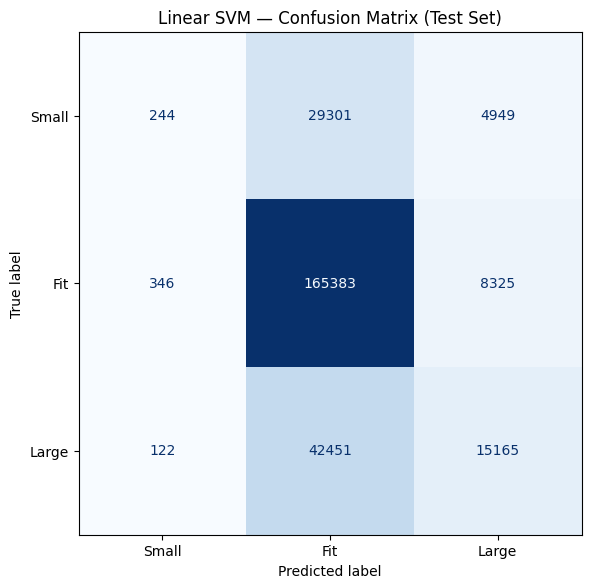

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Small", "Fit", "Large"],
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Linear SVM — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("../../Figures/Supervised_Outputs/Linear_svm_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
svm_proba = best_svm.predict_proba(X_test)

svm_proba_df = pd.DataFrame({
    "user_id": df.loc[X_test.index, "user_id"],
    "item_id": df.loc[X_test.index, "item_id"],
    "true_fit": y_test.values,
    "prob_small": svm_proba[:, 0],
    "prob_fit": svm_proba[:, 1],
    "prob_large": svm_proba[:, 2]
})

svm_proba_df.to_csv(
    "../../Data/Processed/Supervised_Outputs/linear_svm_fit_probabilities.csv",
    index=False
)

In [ ]:
prep = best_svm.named_steps["prep"]

feature_names = []
feature_names.extend(NUMERIC_FEATURES + TOPIC_FEATURES)

cat_encoder = prep.named_transformers_["cat"].named_steps["onehot"]
feature_names.extend(
    cat_encoder.get_feature_names_out(CLUSTER_FEATURES)
)

feature_names.extend(BINARY_FEATURES)

pd.Series(feature_names).to_csv(
    "../../Data/Processed/Supervised_Outputs/linear_svm_feature_names.csv",
    index=False
)

In [ ]:
import joblib

joblib.dump(
    best_svm,
    "../../Models/linear_svm_fit_classifier.joblib"
)

['../Models/linear_svm_fit_classifier.joblib']

Overall Verdict: The model is heavily biased toward "Fit"
The best C=0.1 (very low regularization strength) suggests the model prefers a wide-margin, simple boundary — which in this case means it's taking the easy route of predicting "Fit" for almost everything.

Class-by-Class Breakdown

"Fit" (174k samples — the majority class)

Recall of 0.95 means it catches nearly all true Fit cases
But this is easy — it's just predicting Fit most of the time
The model is essentially over-relying on this class

"Large" (57k samples)

Precision 0.53, recall 0.26 — it misses ~74% of actual Large cases
Moderate when it does predict Large, but rarely bothers to

"Small" (34k samples — minority class)

Recall of 0.01 — essentially never predicts Small
This class is being almost completely ignored
F1 of 0.01 is nearly useless